In [185]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from contextlib import nullcontext

In [186]:
CIFAR100_SUPERCLASSES="""
cifar100-aquatic_mammals
cifar100-fish
cifar100-flowers
cifar100-food_containers
cifar100-fruit_and_vegetables
cifar100-household_electrical_devices
cifar100-household_furniture
cifar100-insects
cifar100-large_carnivores
cifar100-large_man_made_outdoor_things
cifar100-large_natural_outdoor_scenes
cifar100-large_omnivores_and_herbivores
cifar100-medium_mammals
cifar100-non_insect_invertebrates
cifar100-people
cifar100-reptiles
cifar100-small_mammals
cifar100-trees
cifar100-vehicles_1
cifar100-vehicles_2
""".strip().split("\n")

CIFAR100_SUPERCLASSES

['cifar100-aquatic_mammals',
 'cifar100-fish',
 'cifar100-flowers',
 'cifar100-food_containers',
 'cifar100-fruit_and_vegetables',
 'cifar100-household_electrical_devices',
 'cifar100-household_furniture',
 'cifar100-insects',
 'cifar100-large_carnivores',
 'cifar100-large_man_made_outdoor_things',
 'cifar100-large_natural_outdoor_scenes',
 'cifar100-large_omnivores_and_herbivores',
 'cifar100-medium_mammals',
 'cifar100-non_insect_invertebrates',
 'cifar100-people',
 'cifar100-reptiles',
 'cifar100-small_mammals',
 'cifar100-trees',
 'cifar100-vehicles_1',
 'cifar100-vehicles_2']

In [187]:
api = wandb.Api()

In [181]:
EXPERIMENT_GROUP = "./2023-09-s14/distill-layerwise/run1/hyperopt"

In [189]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    training_size,
    use_val_split,
    contamination_level,
    verbose=False,
    
):
    
    assert use_val_split

    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.use_val_split": use_val_split},
            {"config.seed": 1},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            return run
            count += 1
            continue
                     
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )
        
    print("Missing dataset", set(CIFAR100_SUPERCLASSES).difference(datasets))

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
        
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-identity:random--uncentered",
#     policy="fitnet-3l",
    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
    use_val_split=True
)

summary

we have 200 runs
Missing dataset set()
df.shape: (10, 11)


lambda_layer   val_acc                 val_agreement                  \
                    mean       std count          mean       std count   
0          0.0  0.691383  0.113647    20      0.691483  0.113519    20   
1          0.1  0.726754  0.112475    20      0.726854  0.112341    20   
2          1.0  0.747796  0.109799    20      0.747695  0.109939    20   
3         10.0  0.749098  0.106689    20      0.749198  0.106534    20   
4        100.0  0.746593  0.108104    20      0.746693  0.107947    20   
5       1000.0  0.753206  0.109761    20      0.753307  0.109617    20   
6      10000.0  0.754810  0.105397    20      0.754709  0.105557    20   
7     100000.0  0.750802  0.109423    20      0.750902  0.109270    20   
8    1000000.0  0.750401  0.109615    20      0.750501  0.109460    20   
9   10000000.0  0.751603  0.108440    20      0.751503  0.108571    20   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                         0.691383  0.113647    20      0.9999  
1                         0.726754  0.112475    20      0.9999  
2                         0.747695  0.109939    20      0.9999  
3                         0.749098  0.106689    20      0.9999  
4                         0.746593  0.108104    20      0.9999  
5                         0.753206  0.109761    20      0.9999  
6                         0.754709  0.105557    20      0.9999  
7                         0.750802  0.109423    20      0.9999  
8                         0.750401  0.109615    20      0.9999  
9                         0.751503  0.108571    20      0.9999

# Comparison on `cifar100-resnet18-v1`

--- basis-identity:pca--uncentered ----
we have 200 runs
Missing dataset set()
df.shape: (10, 11)
--- basis-identity:prca-sortabs--uncentered ----
we have 200 runs
Missing dataset set()
df.shape: (10, 11)
--- basis-identity:random--uncentered ----
we have 200 runs
Missing dataset set()
df.shape: (10, 11)
--- fitnet ----
we have 200 runs
Missing dataset set()
df.shape: (10, 11)
--- attention-transfer ----
we have 200 runs
Missing dataset set()
df.shape: (10, 11)
--- vid ----
we have 200 runs
Missing dataset set()
df.shape: (10, 11)
--- fitnet-2l ----
we have 200 runs
Missing dataset set()
df.shape: (10, 11)
--- fitnet-3l ----
we have 200 runs
Missing dataset set()
df.shape: (10, 11)


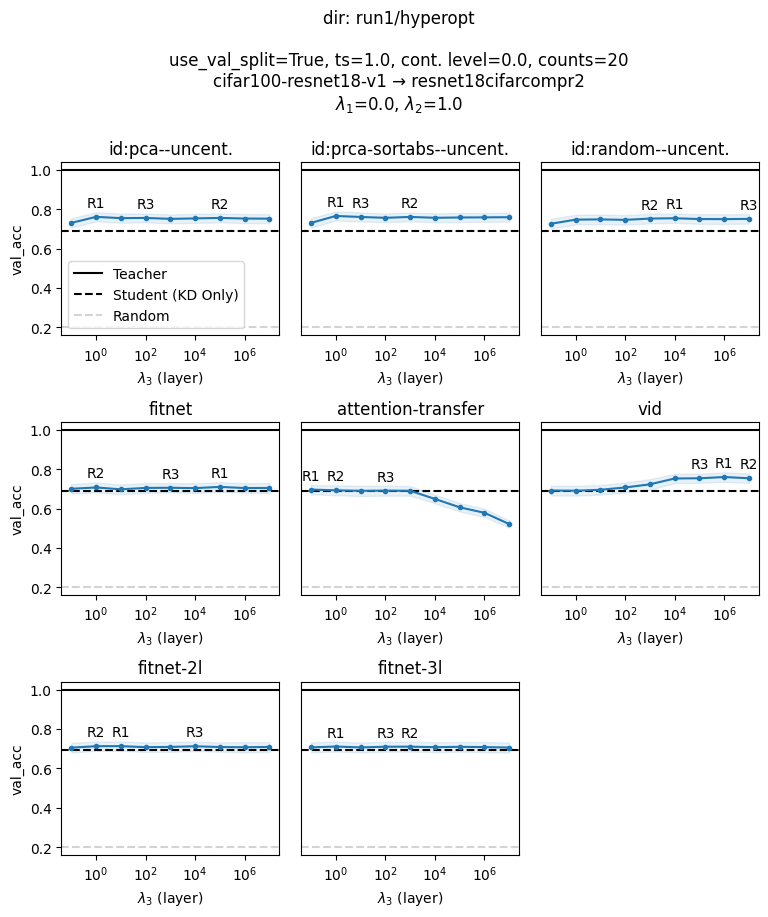

In [197]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    return policy \
        .replace("basis-identity", "id") \
        .replace("uncentered", "uncent.")

    
def viz_distillation(
    teacher, student, policies,  show_legend=True,
):
        

    training_size = 1.0
    contamination_level =0.0
    use_val_split = True
    lambda_kd = 1.0
    lambda_task = 0.0
            
    col = "val_acc"
    
    ncols = 3
    nrows = 3
    
    plt.figure(figsize=(3*ncols, 3*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    for pix, policy in enumerate(policies):
        plt.subplot(nrows, ncols, pix+1)
        plt.title(alias(policy))
        print(f"--- {policy} ----")

        df = read_data(
            teacher=teacher,
            student=student,
            policy=policy,
            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            training_size=training_size,
            contamination_level=contamination_level,
            use_val_split=use_val_split,
            verbose=True
        )
        
        
        with nullcontext(enter_result="sanity check"):            
            if count == None:

                np.testing.assert_equal(
                    df[col]["count"].values,
                    df[col]["count"].values[0]
                )

                count = df[col]["count"].values[0]
            else:
                np.testing.assert_equal(df[col]["count"].values, count)  
                pass 

            if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
                or df[col]["count"].values[0] != count:
                    print(f"[warning] policy={policy}:", df[col]["count"].values)    
        
    

        plt.axhline(
            df["teacher_acc"].values[-1],
            ls="-",
            color="k",
            label="Teacher"
        )
        
        if pix > 0:
            np.testing.assert_allclose(
                acc_student_kd_only,
                df[col]["mean"].values[0],
                atol=1e-2
            )
        else:
            acc_student_kd_only = df[col]["mean"].values[0]
        
        plt.axhline(
            acc_student_kd_only,
            ls="--",
            color="k",
            label="Student (KD Only)"
        )
        
        plt.axhline(0.2, ls="--", color="lightgray", label="Random")
        
        # here, we use [1:] to excluding lambda_layer=0
        assert df["lambda_layer"][0] == 0.0
        ticks = df["lambda_layer"][1:]
        mean = df[col]["mean"][1:]
        stderr = df[col]["std"][1:] / (count ** 0.5)
        
        best_k = np.argmax(df[col]["mean"])
        best_lambda_layer = df["lambda_layer"][best_k]
        
        sorted_indices = np.argsort(-mean.values)
        
        for _i in range(3):
            rix = sorted_indices[_i]

            plt.annotate(
                f"R{_i+1}",
                (ticks.values[rix], mean.values[rix] + 0.05), 
                ha="center",
            )
        

        plt.plot(
            ticks,
            mean,
            marker="."
        )
        
        plt.fill_between(
            ticks,
            mean - stderr,
            mean + stderr,
            alpha=0.1,
            color=plt.gca().lines[-1].get_color()
        )
        

        plt.xscale("log")
        plt.xlabel("$\lambda_3$ (layer)")
        plt.ylabel(col)
        if pix == 0:
            plt.legend()
            
        if pix % ncols != 0:
            plt.ylabel("")
            plt.yticks([])
            
#         if pix // ncols in [3, 2]:
#             plt.xlabel("")
    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"use_val_split={use_val_split}, ts={training_size}, cont. level={contamination_level}, counts={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            "",
        ]),
        y=1.05,
    )
    
    plt.subplots_adjust(hspace=0.5, wspace=0.1)


viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
        f"basis-identity:random--uncentered",
        "fitnet",
        "attention-transfer",
        "vid",
        "fitnet-2l",
        "fitnet-3l",
    ],
) 

# Summary (to be written)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3 = \{0, 10^{-3}, 10^{-2}, \dots,  10^5\}$

*Aims:* 
- find optimal value for these policies

*Conclusion:*
From this experiment, the optimal value for $\lambda_3$  for
- `pca`: `1`
- `prca-sortabs`: `1`
- `random`: 1e4
- `vid`: 1e6
- `attention-transfer`: 0.1
- `fitnet`: 1